In [1]:
import warnings
import logging
from pathlib import Path
import os

import torch
import albumentations as A
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

import thor_terratorch_ext
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import SemanticSegmentationTask

warnings.filterwarnings("ignore", category=UserWarning, module=r"rich\.live")
warnings.filterwarnings("ignore", message=r".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*LeafSpec.*deprecated.*")

logging.getLogger("terratorch").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:thor.models.patch_timm:Patching timm Attention and Block to use Alibi...
INFO:thor.models.patch_timm:Using normal attention for timm Attention


In [2]:
dataset_root = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted")

train_images = dataset_root / "tif_images"
train_masks = dataset_root / "tif_mask"
splits_dir = dataset_root / "splits"

experiment = "thor_s1_icemasks_notebook_run7"
log_root = Path("/home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results")
default_root_dir = log_root / experiment
default_root_dir.mkdir(parents=True, exist_ok=True)

MAX_EPOCHS = 200  

In [3]:
datamodule = GenericMultiModalDataModule(
    task="segmentation",
    batch_size=4,
    num_workers=0,
    modalities=["S1"],
    rgb_modality="S1",
    rgb_indices=[0, 1, 1],

    train_data_root={
        "S1": str(train_images),
    },
    train_label_data_root=str(train_masks),

    val_data_root={
        "S1": str(train_images),
    },
    val_label_data_root=str(train_masks),

    test_data_root={
        "S1": str(train_images),
    },
    test_label_data_root=str(train_masks),

    train_split=str(splits_dir / "train.txt"),
    val_split=str(splits_dir / "val.txt"),
    test_split=str(splits_dir / "test.txt"),

    allow_substring_file_names=True,
    image_grep={
        "S1": "*.tif",
    },
    label_grep="*_mask.tif",

    no_label_replace=-1,
    no_data_replace=0,
    concat_bands=True,
    check_stackability=False,

    dataset_bands={
        "S1": [
            "EW_HH_80",
            "EW_HV_80",
        ],
    },

    means={
        "S1": [
            139.39720896670693,
            126.94754253186677,
        ],
    },
    stds={
        "S1": [
            54.633412799558464,
            47.87104079192851,
        ],
    },

    num_classes=2,

    train_transform=[
        A.RandomCrop(height=288, width=288),
        A.D4(),
        A.pytorch.ToTensorV2(),
    ],
)

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datamodules/generic_multimodal_data_module.py:482: UserWarning: rgb_modality is deprecated and will be removed in a future release. Provide the modalities for plotting as keys in `rgb_indices` with the format {'<modality>': [<band indices>]}.
  warnings.warn("rgb_modality is deprecated and will be removed in a future release. Provide the modalities "


In [12]:
datamodule.setup("fit")

print("train_dataset:", len(datamodule.train_dataset))
print("val_dataset:", len(datamodule.val_dataset))


train_dataset: 95
val_dataset: 20


In [5]:
model_args = {
    "backbone_pretrained": True,
    "backbone": "thor_v1_base",
    "backbone_merge_method": "mean",
    "backbone_input_params": {
        "ground_covers": [23040],
        "flexivit_patch_size_seqs": [8],
    },
    "backbone_out_indices": [-1],
    "backbone_model_bands": [
        "EW_HH_80",
        "EW_HV_80"
    ],
    "decoder": "FCNDecoder",
    "decoder_channels": 256,
    "num_classes": 2,
    "head_dropout": 0.1,
}

task = SemanticSegmentationTask(
    model_args=model_args,
    model_factory="EncoderDecoderFactory",
    loss="ce",
    lr=2e-5,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    scheduler="ReduceLROnPlateau",
    scheduler_hparams={
        "mode": "max",
        "factor": 0.5,
        "patience": 10,
        "threshold": 1e-4,
    },
    tiled_inference_on_validation=True,
    tiled_inference_on_testing=True,
    tiled_inference_parameters={
        "h_crop": 288,
        "h_stride": 256,
        "w_crop": 288,
        "w_stride": 256,
        "average_patches": True,
        "batch_size": 4,
    },
    freeze_backbone=True,
    freeze_decoder=False,
)

INFO:thor_terratorch_ext.models.backbones.thor_vit:Detected GSD suffix: 80 for band: EW_HH, mapped to THOR band: S1:EW-HH
INFO:thor_terratorch_ext.models.backbones.thor_vit:Original channel params: {'GSD': 10, 'patch_size': 16, 'patch_embed_name': 'S1:HH'}, updating GSD to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group members if necessary: ['S1:IW-HV', 'S1:IW-HH', 'S1:EW-HV', 'S1:EW-HH']
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:IW-HV to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:IW-HH to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Updating GSD for group member: S1:EW-HV to 80
INFO:thor_terratorch_ext.models.backbones.thor_vit:Detected GSD suffix: 80 for band: EW_HV, mapped to THOR band: S1:EW-HV
INFO:thor_terratorch_ext.models.backbones.thor_vit:GSD 80 matches default GSD for band S1:EW-HV, no update needed.
/home/predm/venvs/thor_terratorch_ext/.venv/lib/py

In [6]:
logger = TensorBoardLogger(
    save_dir=str(log_root),
    name=experiment,
)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(default_root_dir / "checkpoints"),
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="epoch{epoch:03d}",
    auto_insert_metric_name=False,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    mode="max",
    patience=30,
    min_delta=1e-4,
    check_finite=False,
    verbose=True,
)

trainer = Trainer(
    accelerator="gpu",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    precision="16-mixed",
    max_epochs=MAX_EPOCHS,
    check_val_every_n_epoch=1,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    enable_checkpointing=True,
    default_root_dir=str(default_root_dir),
    logger=logger,
    callbacks=[
        checkpoint_callback,
        LearningRateMonitor(logging_interval="epoch"),
        early_stopping,
    ],
    enable_progress_bar=False,
    enable_model_summary=True,
)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [7]:
trainer.fit(model=task, datamodule=datamodule)

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_icemasks_notebook_run7/checkpoints exists and is not empty.
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 98.1 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 94.1 M                                                                                       
Total params: 98.1 M                                                                                               
Total estimated model params size (MB): 392                                                                        
Modules in train mode: 376                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RGB modalities found (S1A_EW_GRDM_1SDH_20200101T074620_20200101T074719_030604_038191_4358). Sample keys: ['mask', 'image', 'filename', 'prediction'], Dataset rgb_indices modalities: ['S1']
  warnings.warn(f"No RGB modalities found ({suptitle}). Sample keys: {list(sample.keys())}, "
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RGB modalities found (S1A_EW_GRDM_1SDH_20200101T074515_20200101T074619_030604_038191_EBD1). Sample keys: ['mask', 'image', 'filename', 'prediction'], Dataset rgb_indices modalities: ['S1']
  warnings.warn(f"No RGB modalities found ({suptitle}). Sample keys: {list(sample.keys())}, "
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RG

In [8]:
print("Best checkpoint:", checkpoint_callback.best_model_path)

test_metrics = trainer.test(
    model=task,
    datamodule=datamodule,
    ckpt_path="best"
)

test_metrics

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_icemasks_notebook_run7/checkpoints/epoch007.ckpt


Best checkpoint: /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_icemasks_notebook_run7/checkpoints/epoch007.ckpt


INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_icemasks_notebook_run7/checkpoints/epoch007.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.9264670014381409     │
│    test/Boundary_mIoU     │    0.0375065915286541     │
│   test/Class_Accuracy_0   │    0.9302858710289001     │
│   test/Class_Accuracy_1   │    0.9226481318473816     │
│       test/F1_Score       │    0.9264907836914062     │
│        test/IoU_0         │    0.8646157383918762     │
│        test/IoU_1         │    0.8614843487739563     │
│    test/Pixel_Accuracy    │    0.9265018701553345     │
│         test/loss         │    0.20687425136566162    │
│         test/mIoU         │    0.8630500435829163     │
│      test/mIoU_Micro      │    0.8630679249763489     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.20687425136566162,
  'test/Accuracy': 0.9264670014381409,
  'test/Boundary_mIoU': 0.0375065915286541,
  'test/Class_Accuracy_0': 0.9302858710289001,
  'test/Class_Accuracy_1': 0.9226481318473816,
  'test/F1_Score': 0.9264907836914062,
  'test/IoU_0': 0.8646157383918762,
  'test/IoU_1': 0.8614843487739563,
  'test/Pixel_Accuracy': 0.9265018701553345,
  'test/mIoU': 0.8630500435829163,
  'test/mIoU_Micro': 0.8630679249763489}]

In [9]:
best_ckpt = checkpoint_callback.best_model_path
ckpt = torch.load(best_ckpt, map_location="cpu")
task.load_state_dict(ckpt["state_dict"], strict=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
task.to(device)
task.eval()

SemanticSegmentationTask(
  (model): PixelWiseModel(
    (encoder): THOREncoderWrapper(
      (model): ThorViTEncoder(
        (ind_patch_embed): IndFlexiPatchEmbed(
          (patch_embed): ModuleDict(
            (S2:Red): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:Green): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:Blue): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:NIR): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:RE1): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:RE2): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:RE3): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:RE4): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:SWIR1): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:SWIR2): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
            (S2:CoastAerosal):

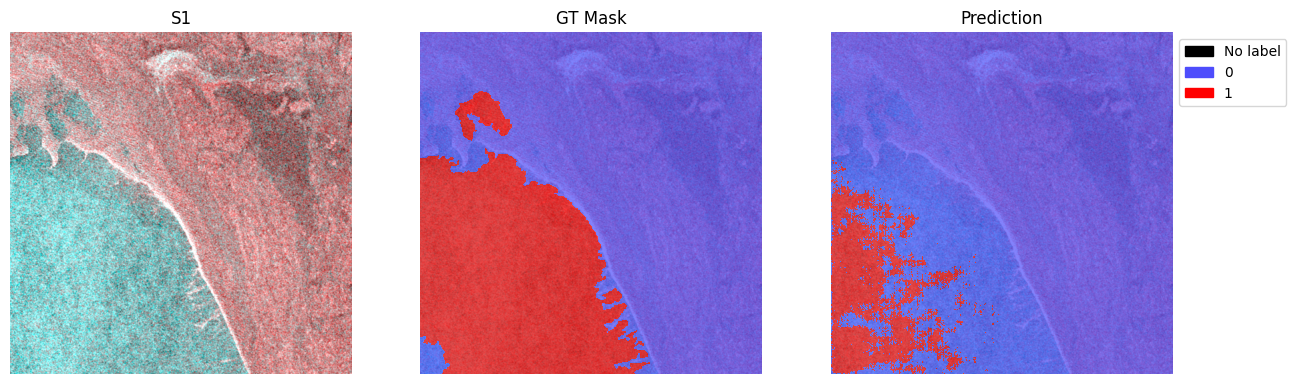

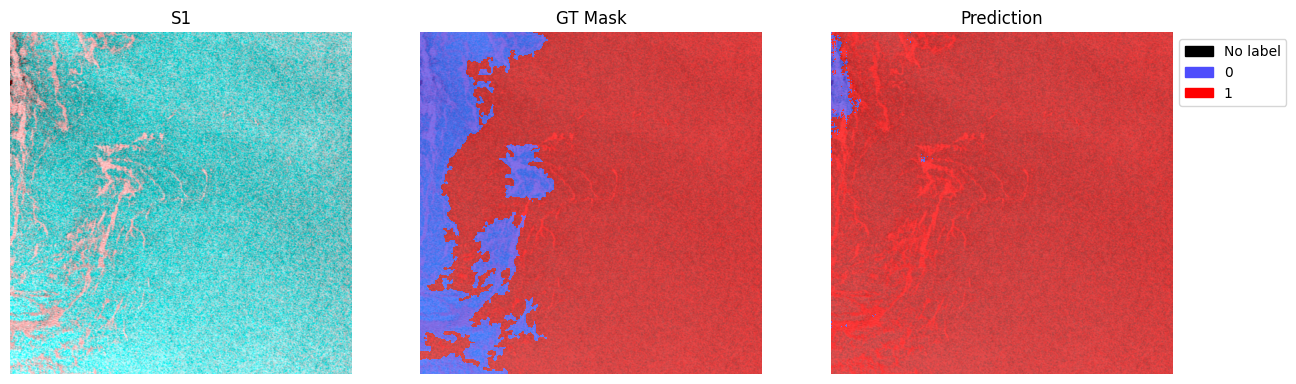

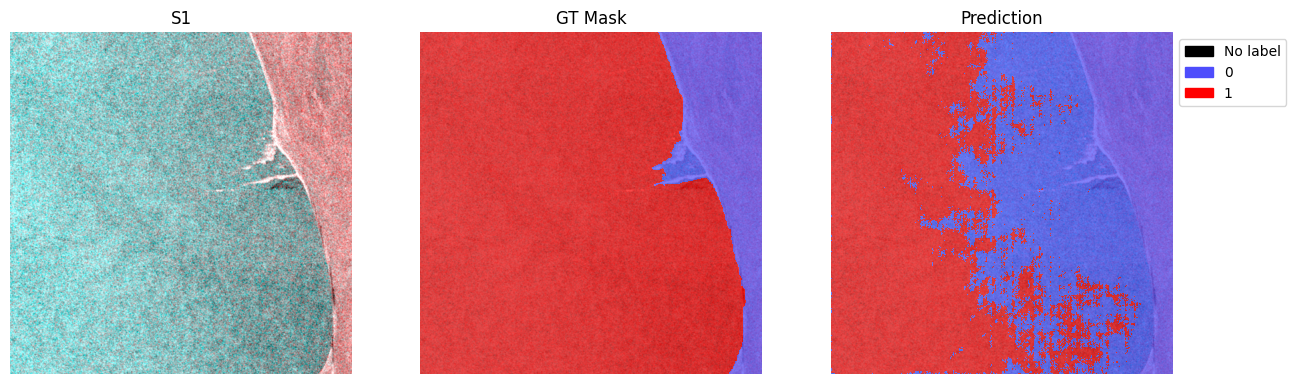

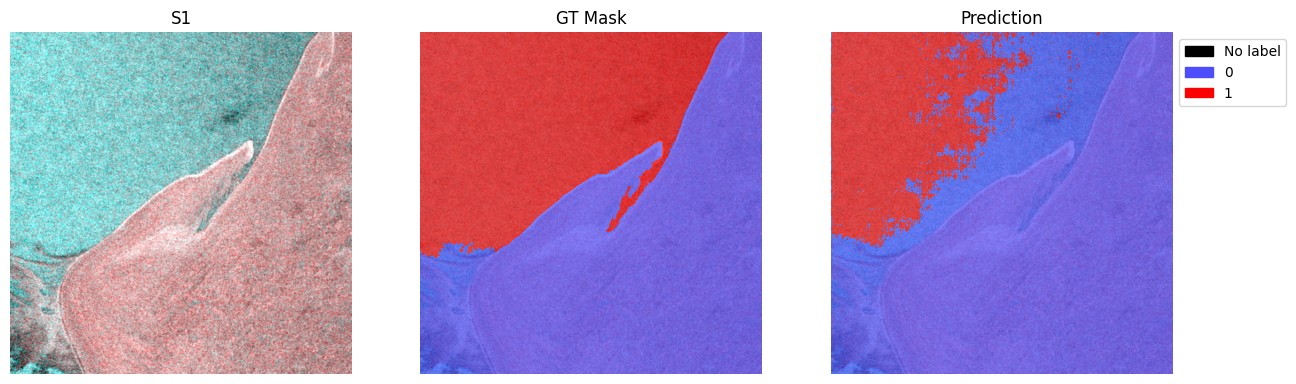

In [10]:
datamodule.setup("test")
test_dataset = datamodule.test_dataset
test_loader = datamodule.test_dataloader()

with torch.no_grad():
    batch_idx = 2  
    for j, batch in enumerate(test_loader):
        if j == batch_idx:
            break

    batch = datamodule.aug(batch)

    images = batch["image"].to(device)
    outputs = task(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

num_examples = min(6, len(preds))

for i in range(num_examples):
    sample = {
    "S1": batch["image"][i][:2].cpu(),
    "mask": batch["mask"][i],
    "prediction": preds[i],
    }
    test_dataset.plot(sample)